In [8]:
from numpy import *
import numpy as np
import numpy.polynomial.polynomial as poly
from matplotlib import pyplot as plt

def nelder_mead(f, x, n):
    """ Búsqueda del mínimo de una función de campo escalar
        mediante el método simplex o nelder-mead.
        @param f: Función de campo escalar
        @param x: Vector de n+1 puntos del simplex
        @param n: Cantidad de iteraciones
    """
    x = np.asarray(sorted(x, key=lambda xi: f(xi)))
    history = [x]
    for i in range(n):
        # Ordenamos 
        x = np.asarray(sorted(x, key=lambda xi: f(xi)))
        
        # Definimos los puntos O, B, P dentro del vector n+1 dimensional
        O = x[0]
        B = x[-2]
        P = x[-1]
        
        print(f'Iteración {i+1} O={O} P={P} B={B}')

        # Primer paso, realizamos la REFLEXIÓN, calculando
        # la posición del baricentro M, y buscando la reflexión R
        M = (O + B) / 2
        R = 2 * M - P
        
        print(f'Reflexión: M={M} R={R}')
        
        if f(R) < f(B):
            if f(O) < f(R):
                # Es peor que el óptimo pero mejor que el peor
                print('La reflexión no era mejor que el óptimo')
                x[-1] = R
            else:
                print('La reflexión era mejor el óptimo')
                # Es mejor que el óptimo, EXPANSIÓN
                E = 3 * M - 2 * P
                print(f'Expansión: E={E}')
                if f(E) < f(O):
                    # Es mejor que el óptimo
                    print('La expansión era mejor el óptimo')
                    x[-1] = E
                else:
                    # Es peor que el óptimo
                    print('La expansión no era mejor el óptimo')
                    x[-1] = R
        else:
            if f(R) < f(P):
                # No es mejor que el bueno, pero sí es mejor
                # que el peor
                print('La reflexión, al menos, es mejor que el peor')
                x[-1] = R
            else:
                # Como la reflexión y expansión no sirven,
                # se prueba con la CONTRACCIÓN
                C1 = (R + M) / 2
                C2 = (P + M) / 2
                C =  C1 if f(C1) < f(C2) else C2
                print(f'Contracción: C1={C1} C2={C2} C={C}')
                
                if f(C) < f(P):
                    # Si la contracción es mejor que el peor
                    print('La contracción era mejor que el peor')
                    x[-1] = C
                else:
                    # Si la contracción no es mejor que el peor
                    # procedo al ENCOGIMIENTO
                    print('La contracción no era mejor, procedemos a encoger')
                    for j in range(1, len(x)):
                        x[j] = (x[j] + O) / 2
                
        # Guardamos historia
        print(x)
        history.append(x)
        
    # Retorno el simplex resultante
    return x, history

def plot_nelder_mead(history):
    """ Función para dibujar los puntos del simplex a lo largo
        del algoritmo. Esta función no es de mi propiedad intelectual,
        fue alterada del código de Gonzalo Davidov y Nicolás Trozzo,
        si estas leyendo esto que al pedo estas.
        @param history: Lista de simplex en cada iteración
    """
    colors = ['r', 'g', 'b', 'c', 'm', 'y']
    for k in range(len(history)):
        x = history[k]
        plt.scatter(x[:,0], x[:,1], c=colors[k % len(colors)], label=f'Iteracion {k}')
        t = plt.Polygon(x, color=colors[k % len(colors)], fill=False)
        plt.gca().add_patch(t)
    plt.legend()
    plt.show()

def steepest_descent(f, grad, xo, n):
    """ Búsqueda del mínimo de la función de campo escalar f,
        dado su gradiente y un punto inicial para partir. Además,
        se define una cantidad máxima de iteraciones.
        @param f: Función a optimizar
        @param grad: Gradiente de la función a optimizar
        @param xo: Punto inicial
        @param n: Cantidad de pasos máximos
    """
    
    # Condiciones iniciales y parámetros
    x = xo
    
    for i in range(n):
        # Calculo la dirección de descenso
        d = -grad(x)
        
        # Busqueda lineal por aproximación cuadrática de la longitud del paso
        g = lambda alfa: f(x + alfa * d)
        alfa_min, h_min = quadratic_aproximation(g, 0, 1)
        
        # Calculo la siguiente posición
        x = x + alfa_min * d
        
        print(f'Iteración {i+1}: x({i+1}) = {x}')
    
    # Retorna posición final
    return x

def quadratic_aproximation(f, xo, ho):
    """ Búsqueda del mínimo de una función mediante búsqueda lineal utilizando
        una interpolación cuadrática, donde se itera hasta encontrar una sonrisa,
        y luego aproximamos el salto.
        @param f: La función cuyo minimo buscamos
        @param xo: El punto inicial del intervalo
        @param ho: El tamaña del salto
    """
    # Definimos los parámetros y condiciones iniciales
    po = (xo, f(xo))
    p1 = (po[0] + ho, f(po[0] + ho))
    p2 = (p1[0] + ho, f(p1[0] + ho))
    
    # Iteramos en la búsqueda del mínimo, en realidad,
    # buscamos formar una sonrisa!
    found = False
    while not found:
        print(f'Iterando ({po[0]}, {po[1]}) - ({p1[0]}, {p1[1]}) - ({p2[0]}, {p2[1]})')
        if po[1] <= p1[1] <= p2[1]:
            ho = ho / 2
            p2 = p1
            p1 = (po[0] + ho, f(po[0] + ho))
        elif p2[1] <= p1[1] <= po[1]:
            ho = ho * 2
            p1 = p2
            p2 = (p1[0] + ho, f(p1[0] + ho))
        else:
            found = True
    
    # Cuando lo encontramos, establecemos una aproximación
    hmin = ho * (4 * p1[1] - 3 * po[1] - p2[1]) / (4 * p1[1] - 2 * po[1] - 2 * p2[1])
    return po[0] + hmin, hmin

def golden_ratio_search(f, a, b, tol=10e-3, max_iter=1000):
    """ Busqueda del mínimo de una función mediante el
        método de la razón áurea. El algoritmo termina después
        de max_iter iteraciones, o cuando la longitud del intervalo
        de búsqueda es inferior a tol.
        @param f: Función para optimizar
        @param a: Cota inferior del intervalo de búsqueda
        @param b: Cota superior del intervalo de búsqueda
        @param tol: Precisión deseada
        @param max_iter: Cantidad de iteraciones
        @return i, a, b
    """
    # Definimos las condiciones iniciales y parámetros
    r = (-1 + np.sqrt(5)) / 2
    c =  a + (b - a) * (1 - r)
    d =  a + (b - a) * r
    yc = f(c)
    yd = f(d)
    # Notifico cada iteración
    print(f'a{0}={a} c{0}={c} d{0}={d} b{0}={b} yc{0}={yc} yd{0}={yd}\n')
    
    # Empezamos a iterar hasta el máximo numero de iteraciones
    for i in range(max_iter):
        
        if yd >= yc:
            b = d
            d = c
            yd = yc
            c = a + (b - a) * (1 - r)
            yc = f(c)
        else:
            a = c
            c = d
            yc = yd
            d = a + (b - a) * r
            yd = f(d)
            
        # Notifico cada iteración
        print(f'a{i+1}={a} c{i+1}={c} d{i+1}={d} b{i+1}={b} yc{i+1}={yc} yd{i+1}={yd}\n')
        
        # En el caso en el que hayamos conseguido pasar la precisión deseada
        if (b - a) < tol:
            break
    
    # Devuelve resultados
    return i+1, a, b

def euler(x0, f, t0, tf, n):
    """ Resolución de un sistema o una ecuación diferencial ordinaria a partir del método Euler, de 1° orden.
        :parametro x0: Condiciones iniciales del problema
        :parametro f: Función de carga
        :parametro t0: Tiempo inicial
        :parametro tf: Tiempo final
        :parametro n: Cantidad de puntos
    """
    t = [t0]
    x = [x0]
    h = (tf - t0) / n
    for i in range(1, n+1):
        t.append(t[i - 1] + h)
        x.append(x[i - 1] + h * f(t[i - 1], x[i - 1]))
    return array(t), array(x)

def heunn(x0, f, t0, tf, n):
    """ Calcula la evolución del sistema o ecuación diferencial empleando como método de aproximación
        el método de Heunn, un método Runge Kutta de segundo orden que emplea aproximación por el área del trapecio.
        :parametro x0: Estado inicial, condiciones iniciales
        :parametro f: Función de carga f(t,x)
        :parametro t0: Tiempo inicial
        :parametro tf: Tiempo final
        :parametro n: Cantidad de puntos
    """
    h = (tf - t0) / n
    t = [t0]
    x = [x0]
    for i in range(1, n+1):
        t.append(t[i - 1] + h)
        k1 = f(t[i-1], x[i-1])
        k2 = f(t[i-1] + h, x[i - 1] + h * k1)
        x.append(x[i - 1] + 0.5 * h * (k1 + k2))
    return array(t), array(x)

def rk4(x0, f, t0, tf, n):
    """ Calcula la evolución del sistema o ecuación diferencial empleando como método de aproximación
        el método de Runge Kutta orden 4.
        :parametro x0: Estado inicial, condiciones iniciales
        :parametro f: Función de carga f(t,x)
        :parametro t0: Tiempo inicial
        :parametro tf: Tiempo final
        :parametro n: Cantidad de puntos
    """
    h = (tf - t0) / n
    t = [t0]
    x = [x0]
    for i in range(1, n+1):
        t.append(t[i - 1] + h)
        k1 = f(t[i-1], x[i-1])
        k2 = f(t[i-1] + h * 0.5, x[i - 1] + 0.5 * h * k1)
        k3 = f(t[i-1] + h * 0.5, x[i - 1] + 0.5 * h * k2)
        k4 = f(t[i-1] + h, x[i - 1] + h * k3)
        x.append(x[i - 1] + h * (k1 + 2 * k2 + 2 * k3 + k4)) / 6
    return array(t), array(x)

def jacobi(A: array, b: array, x0: array, iter_count: int):
    """ Resuelve el sistema lineal mediante el enfoque iterativo
        del método de Jacobi. Para lo cual se requieren matrices que sean
        estrictamente diagonales dominantes. Resuelve:
                                A * x = b
        @param A: Matriz del sistema
        @param b: Condiciones del problema
        @param x0: Condiciones iniciales del problema
        @param iter_count: Cantidad de iteraciones
    """
    if type(A) is not array:
        A = array(A)
    if type(b) is not array:
        b = array(b)
    if type(x0) is not array:
        x0 = array(x0)
    x = zeros((iter_count + 1, len(x0)))
    x[0] = x0
    for n in range(1, iter_count + 1):
        for i in range(len(b)):
            x_i = b[i]
            for j in range(len(b)):
                if j != i:
                    x_i -= A[i][j] * x[n-1][j]
            x_i = x_i / A[i][i]
            x[n][i] = x_i
    return x

def gauss_seidel(A: array, b: array, x0: array, iter_count: int):
    """ Resuelve el sistema lineal mediante el enfoque iterativo
        del método de Gauss Seidel. Para lo cual se requieren matrices que sean
        estrictamente diagonales dominantes o bien definida positiva. Resuelve:
                                A * x = b
        @param A: Matriz del sistema
        @param b: Condiciones del problema
        @param x0: Condiciones iniciales del problema
        @param iter_count: Cantidad de iteraciones
    """
    if type(A) is not array:
        A = array(A)
    if type(b) is not array:
        b = array(b)
    if type(x0) is not array:
        x0 = array(x0)
    x = zeros((iter_count + 1, len(x0)))
    x[0] = x0
    for n in range(1, iter_count + 1):
        for i in range(len(b)):
            x_i = b[i]
            for j in range(len(b)):
                if j < i:
                    x_i -= A[i][j] * x[n][j]
                elif j > i:
                    x_i -= A[i][j] * x[n-1][j]
            x_i = x_i / A[i][i]
            x[n][i] = x_i
    return x

def biseccion(f: callable, a: float, b: float, iter_count: int):
    """ Resuelve el problema de la ecuación no lineal en el intervalo dado,
        básicamente busca el resultado a la ecuación,
            f(x) = 0 con x en [a, b] realizando iter_count iteraciones.
        @param f: Función que describe el problema
        @param a: Cota inferior del intervalo
        @param b: Cota superior del intervalo
        @param iter_count: Cantidad de iteraciones
    """
    if f(a) * f(b) < 0:
        for i in range(1, iter_count + 1):
            c = (a + b) / 2
            if f(a) * f(c) > 0:
                a = c
            elif f(a) * f(c) < 0:
                b = c
            else:
                break
        return c
    else:
        raise ValueError("No cumple las condiciones del problema, puede no haber un cero.")

def punto_fijo(g: callable, x0: float, iter_count: int):
    """ Resolver ecuaciones no lineales por punto fijo.
        @param g: Función de la ecuación a resolver g(x) = x
        @param x0: Condicion inicial
        @param iter_count: Contador de iteraciones
    """
    x = [x0]
    for i in range(1, 1 + iter_count):
        x.append(g(x[i - 1]))
    return x

def newton_raphson(f: callable, f_: callable, x0: float, iter_count: int):
    """ Resolver ecuaciones no lineales por metodo de Newton Raphson
        @param f: Función del problema
        @param f_: Derivada de la función
        @param x0: Condicion inicial
        @param iter_count: Cantidad de pasos
    """
    x = [x0]
    for i in range(1, 1 + iter_count):
        x_i = x[i - 1] - f(x[i - 1])/f_(x[i - 1])
        x.append(x_i)
    return x

def secante(f: callable, x0: float, iter_count: int):
    """ Resolver ecuaciones no lineales por metodo de Secante
        @param f: Función del problema
        @param x0: Condicion inicial
        @param iter_count: Cantidad de pasos
    """
    x = [x0]
    for i in range(1, 1 + iter_count):
        x_i = x[i - 1] - f(x[i - 1]) * ((x[i - 1] - x[i - 2]) / (f(x[i - 1]) - f(x[i - 2])))
        x.append(x_i)
    return x

def lagrange_interpolation(a, b, n, f, cheby):
    """
        Encuentra el polinomio interpolador de 'f' en [a, b] usando polinomios de lagrange de orden n
        @param cheby: True si se usan nodos de chebyshev, de lo contrario equiespaciados
        @return (polinomio, (nodos_x, f(nodos_x)))
            Los coeficientes del polinomio son: [an,..., a1, a0] que el orden en que np.polyval() recibe los coeficientes 
            
        ¡Esta función fue realizada por Rafael Nicolás Trozzo, yo simplemente la copie y pegué.!
    """
    if cheby:
        zj = [np.cos((2*j+1)/(2*(n+1))*np.pi) for j in range(n+1)]
        x_nodes = [(b+a)/2 + (b-a)/2*z for z in zj] 
    else:
        x_nodes = np.linspace(a, b, n + 1)
    y_nodes = [f(x) for x in x_nodes]
    # hay n+1 polinomios con n+1 coeficientes
    lag_pols = np.zeros((n + 1, n + 1)) 
    for k in range(len(x_nodes)):
        # Formamos el polinomio de lagrange k a partir de sus raices
        lag_roots = np.delete(x_nodes, k)
        lag_pols[k] = np.flip(poly.polyfromroots(lag_roots)) / np.prod(x_nodes[k] - lag_roots) * y_nodes[k]
        print(lag_pols[k])  # comentar si no se quieren ver los polinomios de Lagrange
    interp_poly = np.sum(lag_pols, axis=0)
    
    return (interp_poly, (x_nodes, y_nodes))

In [9]:
# Ejercicio 6
x0 = 1
t0 = 0
tf = 0.1
n = 1
f = lambda t, y: np.exp(-y)

heunn(x0, f, t0, tf, n)

(array([0. , 0.1]), array([1.        , 1.03612356]))

Iteración 1 O=[0. 2.] P=[1. 2.] B=[-1. -1.]
Reflexión: M=[-0.5  0.5] R=[-2. -1.]
Contracción: C1=[-1.25 -0.25] C2=[0.25 1.25] C=[0.25 1.25]
La contracción era mejor que el peor
[[ 0.    2.  ]
 [-1.   -1.  ]
 [ 0.25  1.25]]


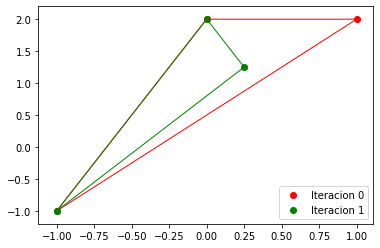

In [12]:
# Ejercicio 2
f = lambda x: (x[0]**2) * (x[1]**2)
x = np.array([
    np.array([-1, -1]),
    np.array([0, 2]),
    np.array([1, 2])
],
    dtype=float
)
n = 1

x, history = nelder_mead(f, x, n)
plot_nelder_mead(history)

In [17]:
def heat_equation(C, r, N, M, u0, u0t, uNt):
    """ 
    heat_equation: computa la solución a la ecuación del calor ut = C * uxx 
    @param C: constante de la ecuación de calor
    @param r: constante de la grilla = k/h^2
    @param N: numero de pasos en x
    @param M: numero de pasos en t
    @param u0: vector de N+1 valores con los valores de u(xi, 0)
    @param u0t: valor de u(0, t)
    @param uNt: valor de u(xN, t)
    """
    # Matriz solucion
    u = np.zeros((N+1, M+1))
    u[:,0] = u0
    u[0] = u0t
    u[N] = uNt
    # ( a1 a2 a3 ) ( uij     )  = v.T * u
    #              ( u(i+1)j )
    #              ( u(i-1)j )
    v = [ 1 - 2*r*C, r*C, r*C ]
    for j in range(0, M):
        for i in range(1, N):
            prev = [ u[i,j], u[i+1,j], u[i-1,j] ]
            u[i,j+1] = np.inner(v, prev)
    return u

# Paso en x
h = 0.25
# Paso en t
k = 0.05
# Cantidad de pasos en x
N = 4
# Cantidad de pasos en t
M = 5
# Condiciones iniciales 
# u(x,0) = 1 - |2x - 1|
u0 = [ np.sin(2 * np.pi * xi) for xi in np.linspace(0, N*h, N + 1)]
# u(0,t) = u(1,t) = 0
u0t = 0
uNt = 0
# Constante de la ecuacion de calor
C = 1
u_ej2 = heat_equation(C, k/h**2, N, M, u0, u0t, uNt)
print(np.round(u_ej2,4))

[[ 0.      0.      0.      0.      0.      0.    ]
 [ 1.     -0.6     0.36   -0.216   0.1296 -0.0778]
 [ 0.     -0.      0.     -0.      0.     -0.    ]
 [-1.      0.6    -0.36    0.216  -0.1296  0.0778]
 [ 0.      0.      0.      0.      0.      0.    ]]
